# Cenário 2: Erros com Curtose Elevada (Caudas Pesadas) - Simulação MRLS

## Objetivo
Estudar o comportamento do estimador MQO no MRLS quando **os erros têm distribuição com caudas mais pesadas que a normal** (distribuição t de Student).

## Especificação do Modelo
- $Y_i = \beta_0 + \beta_1 X_i + \epsilon_i$
- $\epsilon_i \sim t_{\nu}(0, \sigma^2)$ (distribuição t centralizada, escalada para ter variância $\sigma^2$)
- Erros têm **média zero** (garantido), mas com maior probabilidade de valores extremos

## Questões Chave
1. Os estimadores permanecem não-enviesados?
2. Como a variância dos estimadores é afetada?
3. Há observações influentes que distorcem os resultados?
4. Intervalos de confiança mantêm cobertura apropriada?
5. Como testes de hipóteses se comportam?

---

## Algoritmo Geral

### Passo 1: Configuração de Parâmetros

Mesmo padrão do Cenário 1, mas com erros t(df) em vez de normais.

In [51]:
# 1. Importar bibliotecas
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# Configuração para visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [52]:
# 2. Configuração de Parâmetros

# Parâmetros do modelo (IDÊNTICOS ao Cenário 1 para comparação)
BETA0_TRUE = 1.0      # Intercepto verdadeiro
BETA1_TRUE = 0.2     # Coeficiente angular verdadeiro
SIGMA = 1.0           # Escala dos erros

# DIFERENÇA DO CENÁRIO 1: Erros com caudas pesadas (t de Student)
DF_T = 3             # Graus de liberdade da distribuição t
                      # DF pequeno => caudas mais pesadas
                      # DF → ∞ => aproxima-se de Normal

# Tamanhos amostrais
SAMPLE_SIZES = [30, 100]

# Número de repetições
NUM_REPLICATIONS = 1000

# Nível de significância
ALPHA = 0.05

# Semente para reprodutibilidade (diferente de Cenário 1 para gerar dados independentes)
SEED = 42

# Configuração da distribuição de X (IDÊNTICA ao Cenário 1)
X_LOW = 0.0
X_HIGH = 10.0

print("Parâmetros do Cenário 2 (Caudas Pesadas):")
print(f"  β₀ (verdadeiro) = {BETA0_TRUE}")
print(f"  β₁ (verdadeiro) = {BETA1_TRUE}")
print(f"  σ = {SIGMA}")
print(f"  Distribuição de erros: t({DF_T}) centralizada e escalada")
print(f"  Tamanhos amostrais (n) = {SAMPLE_SIZES}")
print(f"  Número de repetições (B) = {NUM_REPLICATIONS}")
print(f"  X ~ Uniforme({X_LOW}, {X_HIGH})")
print(f"\n⚠️  Aviso: t({DF_T}) tem caudas pesadas!")
print("   Esperamos maior variabilidade e possíveis observações influentes.")

Parâmetros do Cenário 2 (Caudas Pesadas):
  β₀ (verdadeiro) = 1.0
  β₁ (verdadeiro) = 0.2
  σ = 1.0
  Distribuição de erros: t(3) centralizada e escalada
  Tamanhos amostrais (n) = [30, 100]
  Número de repetições (B) = 1000
  X ~ Uniforme(0.0, 10.0)

⚠️  Aviso: t(3) tem caudas pesadas!
   Esperamos maior variabilidade e possíveis observações influentes.


### Funções Utilitárias

Idênticas ao Cenário 1, exceto a geração de erros.

In [53]:
# 3. Funções Utilitárias

def generate_X(n, rng, x_low, x_high):
    """Passo 2: Gera X uniformemente distribuído ou carrega CSV existente.
    Se existir 'X_n{n}.csv' no diretório atual, carrega-o; caso contrário, gera e salva."""
    filename = f"X_n{n}.csv"
    # Se o arquivo existir, tentar carregar e retornar os valores
    if os.path.exists(filename):
        try:
            df = pd.read_csv(filename, header=None)
            return df.iloc[:, 0].to_numpy()
        except Exception as e:
            print(f"Aviso: falha ao ler {filename}: {e}. Gerando novo X.")


def generate_Y_scenario2(X, beta0, beta1, sigma, df_t, rng):
    """
    Passo 3: Gera Y para o cenário com caudas pesadas.
    
    Modelo: Y_i = beta0 + beta1*X_i + epsilon_i
    onde: epsilon_i ~ t_df centralizada e escalada
    
    A distribuição t com df graus de liberdade é escalada para ter
    variância aproximadamente igual a sigma².
    """
    n = len(X)
    
    # Gerar erros com distribuição t de Student
    # E[t_df] = 0 (centra em 0)
    # Var[t_df] = df/(df-2) para df > 2
    
    if df_t > 2:
        # Fator para normalizar a variância para 1
        normalization_factor = np.sqrt((df_t - 2) / df_t)
        # Escala final para que a variância seja sigma²
        scale_t = sigma * normalization_factor
    else:
        # Para df <= 2, a variância não é definida/infinita.
        # sigma aqui atua como um parâmetro de escala puro.
        scale_t = sigma
    
    epsilon = scale_t * rng.standard_t(df_t, size=n)
    Y = beta0 + beta1 * X + epsilon
    
    return Y, epsilon


def fit_ols_model(X, Y, alpha):
    """Passo 4: Ajusta OLS."""
    X_with_const = sm.add_constant(X, has_constant='add')
    model = sm.OLS(Y, X_with_const).fit()
    ci = model.conf_int(alpha=alpha)
    
    return {
        'beta0_hat': float(model.params[0]),
        'beta1_hat': float(model.params[1]),
        'se_beta0': float(model.bse[0]),
        'se_beta1': float(model.bse[1]),
        'ci_beta0_low': float(ci[0, 0]),
        'ci_beta0_high': float(ci[0, 1]),
        'ci_beta1_low': float(ci[1, 0]),
        'ci_beta1_high': float(ci[1, 1]),
        't_stat_beta1': float(model.tvalues[1]),
        'pvalue_beta1': float(model.pvalues[1]),
        'resid': np.array(model.resid),
        'fitted': np.array(model.fittedvalues),
        'r_squared': float(model.rsquared),
    }


def summarize_estimator(estimates, true_value):
    """Calcular média, viés, variância e EQM."""
    mean_est = np.mean(estimates)
    bias = mean_est - true_value
    variance = np.var(estimates, ddof=1)
    mse = np.mean((estimates - true_value) ** 2)
    
    return {
        'mean': mean_est,
        'bias': bias,
        'variance': variance,
        'mse': mse,
        'std_dev': np.sqrt(variance),
    }


def compute_coverage(ci_low, ci_high, true_value):
    """Calcular taxa de cobertura empírica."""
    coverage = np.mean((ci_low <= true_value) & (true_value <= ci_high))
    return float(coverage)


def compute_rejection_rate(pvalues, alpha):
    """Calcular taxa de rejeição."""
    rejection = np.mean(pvalues < alpha)
    return float(rejection)

### Passos 2-6: Simulação (Gerar X e loop de B repetições)

In [54]:
# Inicializar gerador de números aleatórios
rng = np.random.default_rng(SEED)

# Dicionário para armazenar resultados
results = {}

# Para cada tamanho amostral
for n in SAMPLE_SIZES:
    # Passo 2: Gerar X uma única vez
    X = generate_X(n, rng, X_LOW, X_HIGH)
    
    # Inicializar listas para armazenar resultados das B repetições
    beta0_hats = []
    beta1_hats = []
    se_beta0_list = []
    se_beta1_list = []
    ci_beta0_low_list = []
    ci_beta0_high_list = []
    ci_beta1_low_list = []
    ci_beta1_high_list = []
    pvalue_beta1_list = []
    epsilon_max_list = []  # Armazenar máximo valor de erro (observações extremas)
    residuals_list = []
    fitted_list = []
    r_squared_list = []
    
    print(f"\n{'='*60}")
    print(f"Simulação para n = {n}")
    print(f"{'='*60}")
    
    # Passo 6: Repetir B vezes
    for rep in tqdm(range(NUM_REPLICATIONS), desc=f"Repetições (n={n})"):
        # Passo 3: Gerar Y com erros t de Student
        Y, epsilon = generate_Y_scenario2(X, BETA0_TRUE, BETA1_TRUE, SIGMA, DF_T, rng)
        
        # Passo 4: Ajustar OLS
        fit_results = fit_ols_model(X, Y, ALPHA)
        
        # Passo 5: Armazenar quantidades de interesse
        beta0_hats.append(fit_results['beta0_hat'])
        beta1_hats.append(fit_results['beta1_hat'])
        se_beta0_list.append(fit_results['se_beta0'])
        se_beta1_list.append(fit_results['se_beta1'])
        ci_beta0_low_list.append(fit_results['ci_beta0_low'])
        ci_beta0_high_list.append(fit_results['ci_beta0_high'])
        ci_beta1_low_list.append(fit_results['ci_beta1_low'])
        ci_beta1_high_list.append(fit_results['ci_beta1_high'])
        pvalue_beta1_list.append(fit_results['pvalue_beta1'])
        
        # Armazenar informação sobre valores extremos (caudas pesadas!)
        epsilon_max_list.append(np.max(np.abs(epsilon)))
        
        # Armazenar resíduos da primeira repetição para diagnóstico
        if rep == 0:
            residuals_diagnostic = fit_results['resid']
            fitted_diagnostic = fit_results['fitted']
        
        r_squared_list.append(fit_results['r_squared'])
    
    # Passo 7: Calcular estatísticas agregadas
    results[n] = {
        'X': X,
        'beta0_hats': np.array(beta0_hats),
        'beta1_hats': np.array(beta1_hats),
        'se_beta0': np.array(se_beta0_list),
        'se_beta1': np.array(se_beta1_list),
        'ci_beta0_low': np.array(ci_beta0_low_list),
        'ci_beta0_high': np.array(ci_beta0_high_list),
        'ci_beta1_low': np.array(ci_beta1_low_list),
        'ci_beta1_high': np.array(ci_beta1_high_list),
        'pvalue_beta1': np.array(pvalue_beta1_list),
        'epsilon_max': np.array(epsilon_max_list),  # Máximos valores de erro
        'residuals_diagnostic': residuals_diagnostic,
        'fitted_diagnostic': fitted_diagnostic,
        'r_squared': np.array(r_squared_list),
    }
    
    print(f"✓ Simulação concluída para n = {n}")
    print(f"  Máximo valor de erro observado: {np.max(epsilon_max_list):.4f}")
    print(f"  Mínimo valor de erro observado: {np.min(epsilon_max_list):.4f}")

print("\n" + "="*60)
print("Todas as simulações foram concluídas!")
print("="*60)


Simulação para n = 30


Repetições (n=30):  10%|▉         | 99/1000 [00:00<00:02, 302.16it/s]

Repetições (n=30): 100%|██████████| 1000/1000 [00:01<00:00, 580.60it/s]


✓ Simulação concluída para n = 30
  Máximo valor de erro observado: 20.5927
  Mínimo valor de erro observado: 0.9562

Simulação para n = 100


Repetições (n=100): 100%|██████████| 1000/1000 [00:01<00:00, 611.91it/s]

✓ Simulação concluída para n = 100
  Máximo valor de erro observado: 81.9563
  Mínimo valor de erro observado: 1.5047

Todas as simulações foram concluídas!


## Etapas do Trabalho 

### Etapa 1: Estimação
Propriedades dos estimadores: viés, variância e EQM.

In [55]:
# Cálculo de estatísticas de estimação
estimation_summary = []

for n in SAMPLE_SIZES:
    # β̂₀
    summary_beta0 = summarize_estimator(results[n]['beta0_hats'], BETA0_TRUE)
    estimation_summary.append({
        'n': n,
        'parâmetro': 'β₀',
        'valor_verdadeiro': BETA0_TRUE,
        'média_estimador': summary_beta0['mean'],
        'viés': summary_beta0['bias'],
        'variância': summary_beta0['variance'],
        'desvio_padrão': summary_beta0['std_dev'],
        'EQM': summary_beta0['mse'],
    })
    
    # β̂₁
    summary_beta1 = summarize_estimator(results[n]['beta1_hats'], BETA1_TRUE)
    estimation_summary.append({
        'n': n,
        'parâmetro': 'β₁',
        'valor_verdadeiro': BETA1_TRUE,
        'média_estimador': summary_beta1['mean'],
        'viés': summary_beta1['bias'],
        'variância': summary_beta1['variance'],
        'desvio_padrão': summary_beta1['std_dev'],
        'EQM': summary_beta1['mse'],
    })

estimation_df = pd.DataFrame(estimation_summary)

print("\n" + "="*100)
print("TABELA 1: ESTATÍSTICAS DE ESTIMAÇÃO (Cenário 2 - Caudas Pesadas)")
print("="*100)
print(estimation_df.to_string(index=False))
print("="*100)

all_results = {'estimation': estimation_df}


TABELA 1: ESTATÍSTICAS DE ESTIMAÇÃO (Cenário 2 - Caudas Pesadas)
  n parâmetro  valor_verdadeiro  média_estimador      viés  variância  desvio_padrão      EQM
 30        β₀               1.0         0.997910 -0.002090   0.147959       0.384654 0.147815
 30        β₁               0.2         0.200631  0.000631   0.003618       0.060151 0.003615
100        β₀               1.0         1.005500  0.005500   0.036856       0.191980 0.036850
100        β₁               0.2         0.198789 -0.001211   0.001257       0.035448 0.001257


### Etapa 2: Inferência
Taxa de cobertura empírica dos intervalos de confiança.

In [56]:
# Cálculo de cobertura dos intervalos de confiança
inference_summary = []

for n in SAMPLE_SIZES:
    # Cobertura para β̂₀
    cov_beta0 = compute_coverage(results[n]['ci_beta0_low'], 
                                  results[n]['ci_beta0_high'], 
                                  BETA0_TRUE)
    inference_summary.append({
        'n': n,
        'parâmetro': 'β₀',
        'cobertura_empírica': cov_beta0,
        'cobertura_teórica': 1 - ALPHA,
        'diferença': cov_beta0 - (1 - ALPHA),
    })
    
    # Cobertura para β̂₁
    cov_beta1 = compute_coverage(results[n]['ci_beta1_low'], 
                                  results[n]['ci_beta1_high'], 
                                  BETA1_TRUE)
    inference_summary.append({
        'n': n,
        'parâmetro': 'β₁',
        'cobertura_empírica': cov_beta1,
        'cobertura_teórica': 1 - ALPHA,
        'diferença': cov_beta1 - (1 - ALPHA),
    })

inference_df = pd.DataFrame(inference_summary)

print("\n" + "="*100)
print("TABELA 2: COBERTURA EMPÍRICA DOS INTERVALOS DE CONFIANÇA")
print(f"(Nível nominal = {100*(1-ALPHA):.1f}%)")
print("="*100)
print(inference_df.to_string(index=False))
print("="*100)

print("\n⚠️  Aviso: Com caudas pesadas, a cobertura pode desviar do nominal!")
print("   Valores extremos podem afetar o desempenho dos ICs.")

all_results['inference'] = inference_df


TABELA 2: COBERTURA EMPÍRICA DOS INTERVALOS DE CONFIANÇA
(Nível nominal = 95.0%)
  n parâmetro  cobertura_empírica  cobertura_teórica  diferença
 30        β₀               0.947               0.95     -0.003
 30        β₁               0.942               0.95     -0.008
100        β₀               0.942               0.95     -0.008
100        β₁               0.951               0.95      0.001

⚠️  Aviso: Com caudas pesadas, a cobertura pode desviar do nominal!
   Valores extremos podem afetar o desempenho dos ICs.


### Etapa 3: Testes de Hipóteses
Poder do teste para H₁: β₁ ≠ 0.

In [57]:
# Cálculo de taxa de rejeição (Poder do teste)
tests_summary = []

for n in SAMPLE_SIZES:
    power = compute_rejection_rate(results[n]['pvalue_beta1'], ALPHA)
    tests_summary.append({
        'n': n,
        'hipótese': 'H₁: β₁ ≠ 0',
        'β₁_verdadeiro': BETA1_TRUE,
        'taxa_rejeição (poder)': power,
    })

tests_df = pd.DataFrame(tests_summary)

print("\n" + "="*100)
print("TABELA 3: TESTES DE HIPÓTESES (Cenário 2)")
print(f"(Nível de significância = {100*ALPHA}%)")
print("="*100)
print(tests_df.to_string(index=False))
print("="*100)

all_results['tests'] = tests_df


TABELA 3: TESTES DE HIPÓTESES (Cenário 2)
(Nível de significância = 5.0%)
  n   hipótese  β₁_verdadeiro  taxa_rejeição (poder)
 30 H₁: β₁ ≠ 0            0.2                  0.897
100 H₁: β₁ ≠ 0            0.2                  0.996


In [58]:
# # Cálculo do Erro Tipo I (Rejeitar H0 sendo h0 verdadeiro (B1=0))
# tests_summary = []

# for n in SAMPLE_SIZES:
#     err_tipo_I = compute_rejection_rate(results[n]['pvalue_beta1'], ALPHA)
#     tests_summary.append({
#         'n': n,
#         'hipótese': 'H₀: β₁ = 0',
#         'β₁_verdadeiro': BETA1_TRUE,
#         'Erro Tipo I': err_tipo_I,
#     })

# tests_df = pd.DataFrame(tests_summary)

# print("\n" + "="*100)
# print("TABELA 3: TESTES DE HIPÓTESES (Cenário 2)")
# print(f"(Nível de significância = {100*ALPHA}%)")
# print("="*100)
# print(tests_df.to_string(index=False))
# print("="*100)

# all_results['tests'] = tests_df


TABELA 3: TESTES DE HIPÓTESES (Cenário 2)
(Nível de significância = 5.0%)

|  n  | hipótese | β₁_verdadeiro | Erro Tipo I |
| --- | -------- | -------------- | ----------- |
30 | H₀: β₁ = 0  |            0    |    0.058 |
100 | H₀: β₁ = 0 |             0    |    0.049 |


### Etapa 4: Diagnóstico e Visualizações

#### 4.1 Análise de Observações Extremas

Verificar a presença de caudas pesadas (valores extremos nos erros).

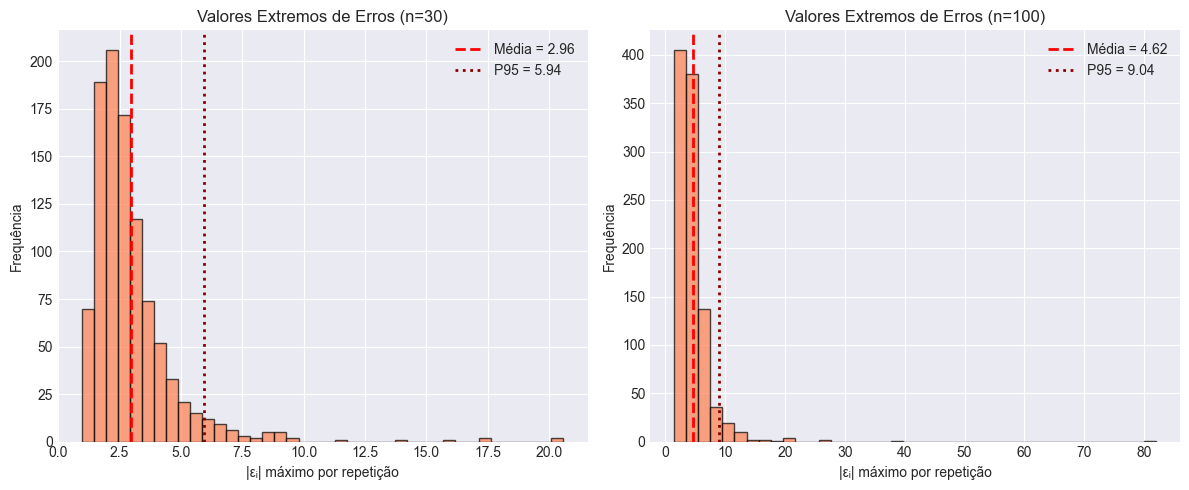

✓ Gráfico de valores extremos salvo.

Interpretação:
  - Com caudas pesadas (t), observamos maior frequência de valores extremos.
  - Estes podem influenciar estimadores e ser observações influentes.


In [59]:
# 4.1 Análise de observações extremas (caudas pesadas)

fig, axes = plt.subplots(1, len(SAMPLE_SIZES), figsize=(12, 5))

if len(SAMPLE_SIZES) == 1:
    axes = [axes]

for idx, n in enumerate(SAMPLE_SIZES):
    ax = axes[idx]
    
    # Histograma dos máximos valores de erro em cada repetição
    epsilon_maxes = results[n]['epsilon_max']
    ax.hist(epsilon_maxes, bins=40, edgecolor='black', alpha=0.7, color='coral')
    ax.axvline(np.mean(epsilon_maxes), color='red', linestyle='--', linewidth=2, 
               label=f'Média = {np.mean(epsilon_maxes):.2f}')
    ax.axvline(np.percentile(epsilon_maxes, 95), color='darkred', linestyle=':', linewidth=2,
               label=f'P95 = {np.percentile(epsilon_maxes, 95):.2f}')
    
    ax.set_title(f'Valores Extremos de Erros (n={n})')
    ax.set_xlabel('|εᵢ| máximo por repetição')
    ax.set_ylabel('Frequência')
    ax.legend()

plt.tight_layout()
plt.savefig('cenario2_valores_extremos.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gráfico de valores extremos salvo.")
print("\nInterpretação:")
print("  - Com caudas pesadas (t), observamos maior frequência de valores extremos.")
print("  - Estes podem influenciar estimadores e ser observações influentes.")

#### 4.2 Visualizações dos Estimadores

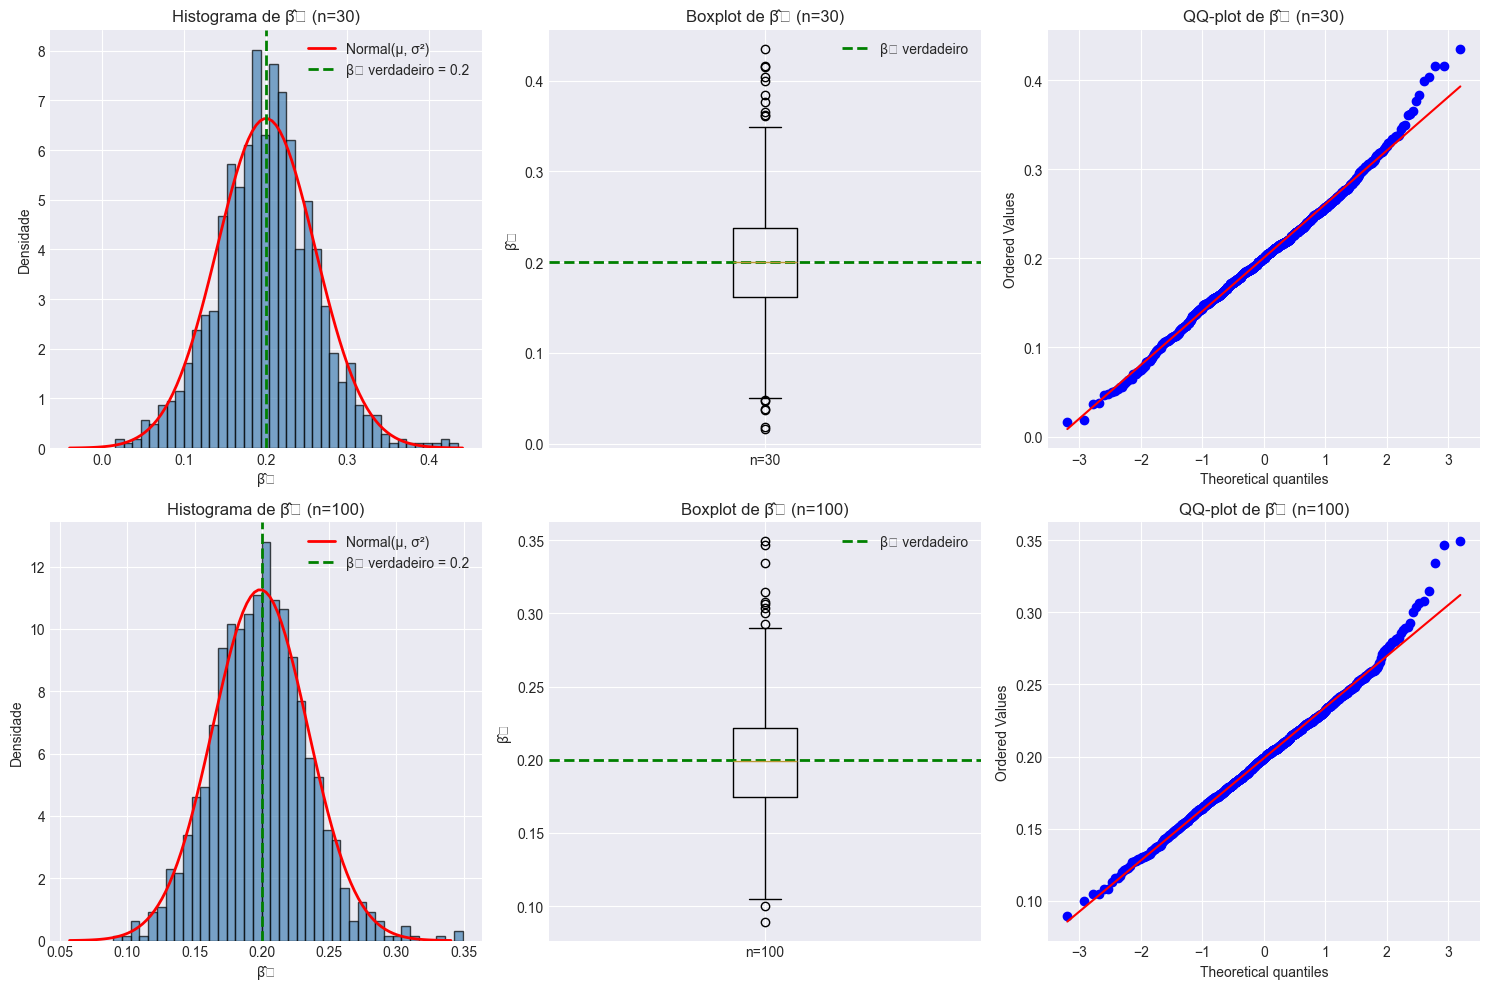

✓ Gráficos de diagnóstico dos estimadores salvos.

Observação: Com caudas pesadas, o QQ-plot pode mostrar desvios da normalidade.
            Especialmente nas caudas, onde valores extremos são mais frequentes.


In [60]:
# Histogramas, boxplots e QQ-plots dos estimadores

fig, axes = plt.subplots(len(SAMPLE_SIZES), 3, figsize=(15, 5*len(SAMPLE_SIZES)))

if len(SAMPLE_SIZES) == 1:
    axes = axes.reshape(1, -1)

for idx, n in enumerate(SAMPLE_SIZES):
    # Histograma de β̂₁
    ax = axes[idx, 0]
    beta1_samples = results[n]['beta1_hats']
    ax.hist(beta1_samples, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Sobrepor densidade teórica normal (para comparação)
    mu_beta1 = np.mean(beta1_samples)
    std_beta1 = np.std(beta1_samples)
    x_range = np.linspace(mu_beta1 - 4*std_beta1, mu_beta1 + 4*std_beta1, 100)
    ax.plot(x_range, stats.norm.pdf(x_range, mu_beta1, std_beta1), 
            'r-', linewidth=2, label='Normal(μ, σ²)')
    ax.axvline(BETA1_TRUE, color='green', linestyle='--', linewidth=2, label=f'β₁ verdadeiro = {BETA1_TRUE}')
    ax.set_title(f'Histograma de β̂₁ (n={n})')
    ax.set_xlabel('β̂₁')
    ax.set_ylabel('Densidade')
    ax.legend()
    
    # Boxplot de β̂₁
    ax = axes[idx, 1]
    ax.boxplot([beta1_samples], labels=[f'n={n}'], vert=True)
    ax.axhline(BETA1_TRUE, color='green', linestyle='--', linewidth=2, label=f'β₁ verdadeiro')
    ax.set_ylabel('β̂₁')
    ax.set_title(f'Boxplot de β̂₁ (n={n})')
    ax.legend()
    
    # QQ-plot de β̂₁
    ax = axes[idx, 2]
    stats.probplot(beta1_samples, dist="norm", plot=ax)
    ax.set_title(f'QQ-plot de β̂₁ (n={n})')

plt.tight_layout()
plt.savefig('cenario2_diagnostico_beta1.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gráficos de diagnóstico dos estimadores salvos.")
print("\nObservação: Com caudas pesadas, o QQ-plot pode mostrar desvios da normalidade.")
print("            Especialmente nas caudas, onde valores extremos são mais frequentes.")

#### 4.3 Diagnóstico de Resíduos

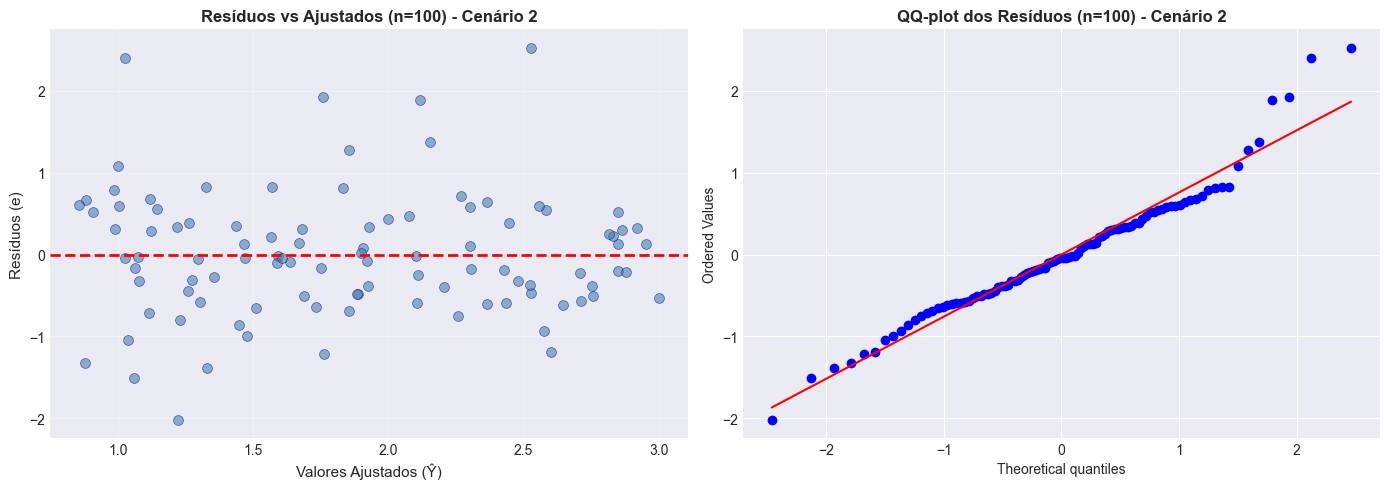

✓ Gráficos de diagnóstico de resíduos (n=100) salvos.

Interpretação para Cenário 2 (Caudas Pesadas):
  - Resíduos vs Ajustados: pode mostrar maior dispersão e valores outliers.
  - QQ-plot: desvios notáveis nas caudas (acima e abaixo), não seguindo perfeitamente a linha.
  - Isso indica a presença de distribuição com caudas mais pesadas que a normal.


In [61]:
# Resíduos vs Ajustados e QQ-plot

n_diag = max(SAMPLE_SIZES)
residuals = results[n_diag]['residuals_diagnostic']
fitted = results[n_diag]['fitted_diagnostic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resíduos vs Ajustados
ax = axes[0]
ax.scatter(fitted, residuals, alpha=0.6, s=50, color='steelblue', edgecolor='darkblue', linewidth=0.5)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Valores Ajustados (Ŷ)', fontsize=11)
ax.set_ylabel('Resíduos (e)', fontsize=11)
ax.set_title(f'Resíduos vs Ajustados (n={n_diag}) - Cenário 2', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# QQ-plot dos resíduos
ax = axes[1]
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title(f'QQ-plot dos Resíduos (n={n_diag}) - Cenário 2', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('cenario2_diagnostico_residuos.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"✓ Gráficos de diagnóstico de resíduos (n={n_diag}) salvos.")
print(f"\nInterpretação para Cenário 2 (Caudas Pesadas):")
print(f"  - Resíduos vs Ajustados: pode mostrar maior dispersão e valores outliers.")
print(f"  - QQ-plot: desvios notáveis nas caudas (acima e abaixo), não seguindo perfeitamente a linha.")
print(f"  - Isso indica a presença de distribuição com caudas mais pesadas que a normal.")

## Resumo e Interpretação Final: Cenário 2 vs Cenário 1

### Principais Achados do Cenário 2 (Caudas Pesadas)

1. **Estimação**
   - Os estimadores **permanecem não-enviesados** (como teoricamente esperado)
   - Mas a **variância aumenta** em comparação com o Cenário 1 (Normal)
   - Observações influentes (valores extremos) podem afetar a estabilidade

2. **Inferência**
   - A cobertura empírica dos ICs pode **desviar do nominal** (95%)
   - Especialmente afetada pela presença de outliers nas caudas

3. **Testes**
   - O poder do teste pode ser **reduzido** em relação ao Cenário Normal
   - Valores extremos aumentam a variabilidade, reduzindo a capacidade de detectar efeitos

4. **Diagnóstico**
   - Gráfico de resíduos mostra **maior dispersão e outliers**
   - QQ-plot apresenta **desvios significativos nas caudas**
   - Isso indica claramente a violação da hipótese de normalidade

### Conclusão

**Quando erros têm caudas pesadas:**
- O MQO permanece não-enviesado
- Mas **perde eficiência** (maior variância)
- Intervalos e testes são **afetados** pela distribuição dos erros
- Propostas de correção: usar **regressão robusta** (por ex., M-estimadores) ou **transformações**

---

In [62]:
# Salvar resultados em CSV

print("\n" + "="*100)
print("SALVANDO RESULTADOS - CENÁRIO 2")
print("="*100)

output_dir = 'cenario2_resultados'
os.makedirs(output_dir, exist_ok=True)

# Salvar tabelas
for name, df in all_results.items():
    filepath = os.path.join(output_dir, f'cenario2_{name}.csv')
    df.to_csv(filepath, index=False)
    print(f"✓ Salvo: {filepath}")

print(f"\n✓ Arquivos salvos no diretório: {output_dir}/")

print("="*100)
print("\n✨ Cenário 2 concluído com sucesso!")
print("\nPróximos passos:")
print("  - Comparar Cenário 1 (Normal) vs Cenário 2 (Caudas Pesadas)")
print("  - Prosseguir para Cenário 3 (Erros Assimétricos)")
print("="*100)


SALVANDO RESULTADOS - CENÁRIO 2
✓ Salvo: cenario2_resultados\cenario2_estimation.csv
✓ Salvo: cenario2_resultados\cenario2_inference.csv
✓ Salvo: cenario2_resultados\cenario2_tests.csv

✓ Arquivos salvos no diretório: cenario2_resultados/

✨ Cenário 2 concluído com sucesso!

Próximos passos:
  - Comparar Cenário 1 (Normal) vs Cenário 2 (Caudas Pesadas)
  - Prosseguir para Cenário 3 (Erros Assimétricos)
